In [1]:
print("Hello, Iris Classification!")

Hello, Iris Classification!


In [5]:
from sklearn.datasets import load_iris

In [9]:
iris = load_iris()

In [13]:
# Iris dataset-এর feature names
print("Feature Names:")
print(iris.feature_names)

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [15]:
# Target/species-এর নাম
print("\nTarget Names:")
print(iris.target_names)


Target Names:
['setosa' 'versicolor' 'virginica']


In [17]:
# Dataset-এর shape
print("\nDataset Shape:")
print(iris.data.shape)


Dataset Shape:
(150, 4)


In [19]:
# প্রথম 5টি data দেখানো
print("\nFirst 5 Rows:")
print(iris.data[:5])


First 5 Rows:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [21]:
# প্রথম 5টি target দেখানো
print("\nFirst 5 Targets:")
print(iris.target[:5])


First 5 Targets:
[0 0 0 0 0]


In [23]:
import pandas as pd

# Iris-এর feature data দিয়ে DataFrame তৈরি
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Target/species column যোগ করা
df["species"] = iris.target

# প্রথম 5টি row দেখা
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [25]:
# Dataset-এর shape
print("Shape:")
print(df.shape)

# প্রতিটি column-এর data type
print("\nData Types:")
print(df.dtypes)

# Missing/Null values
print("\nMissing Values:")
print(df.isnull().sum())

# Descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())

Shape:
(150, 5)

Data Types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int32
dtype: object

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Descriptive Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)     species  
count        150.0

In [27]:
# Species number থেকে species name তৈরি করা
species_names = {
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
}

df["species_name"] = df["species"].map(species_names)

# প্রথম 10টি row দেখা
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa
5,5.4,3.9,1.7,0.4,0,Setosa
6,4.6,3.4,1.4,0.3,0,Setosa
7,5.0,3.4,1.5,0.2,0,Setosa
8,4.4,2.9,1.4,0.2,0,Setosa
9,4.9,3.1,1.5,0.1,0,Setosa


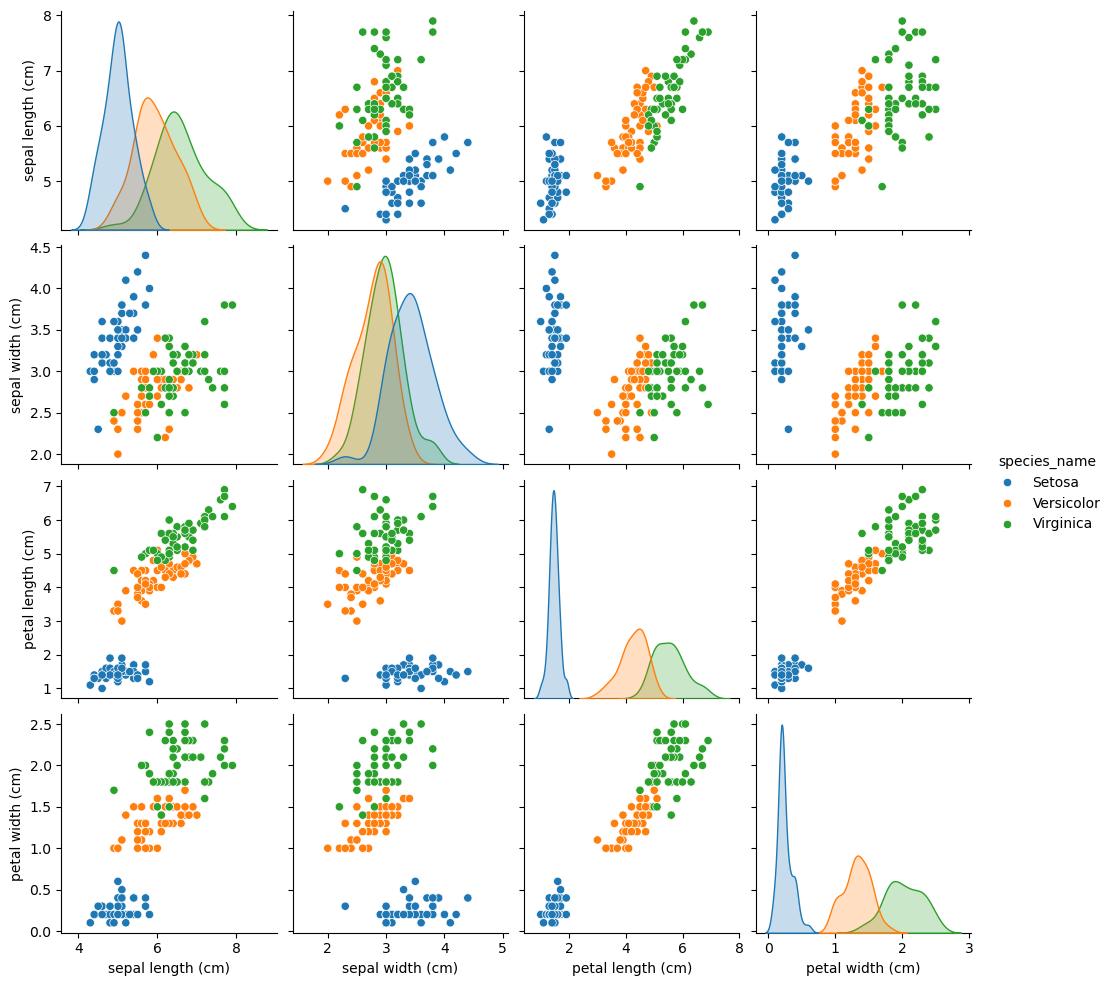

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Iris features-এর relationship এবং species অনুযায়ী distribution দেখা
sns.pairplot(
    df,
    x_vars=[
        "sepal length (cm)",
        "sepal width (cm)",
        "petal length (cm)",
        "petal width (cm)"
    ],
    y_vars=[
        "sepal length (cm)",
        "sepal width (cm)",
        "petal length (cm)",
        "petal width (cm)"
    ],
    hue="species_name"
)

plt.show()

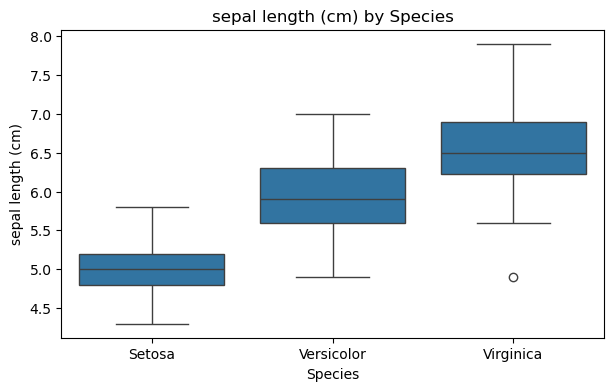

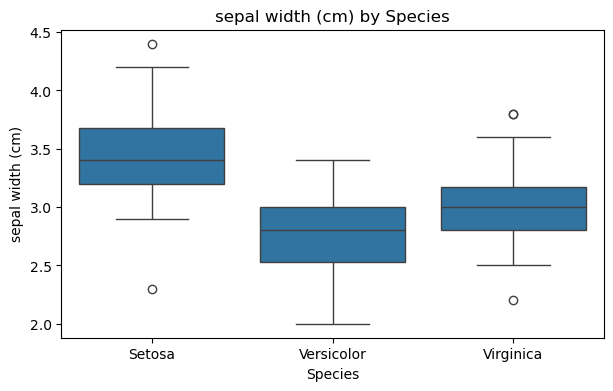

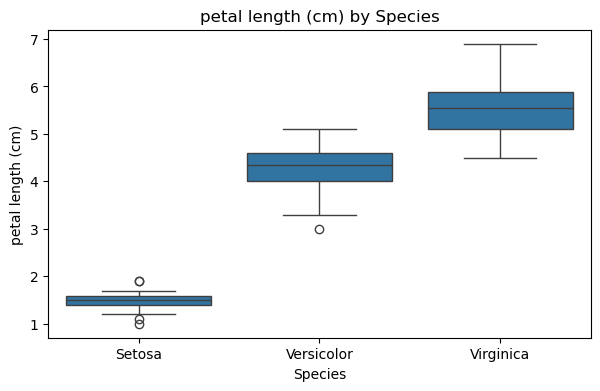

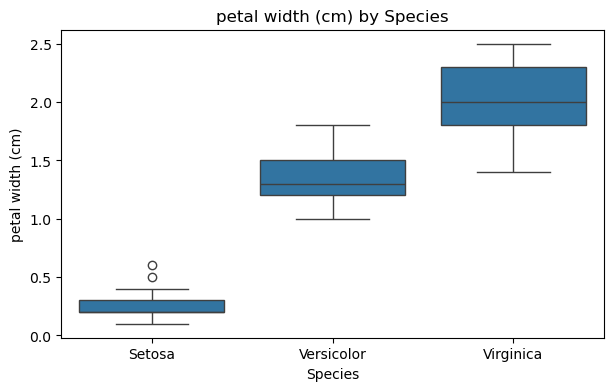

In [32]:
# চারটি numerical feature
features = [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
]

# প্রতিটি feature-এর জন্য box plot
for feature in features:
    plt.figure(figsize=(7, 4))
    
    sns.boxplot(
        data=df,
        x="species_name",
        y=feature
    )
    
    plt.title(f"{feature} by Species")
    plt.xlabel("Species")
    plt.ylabel(feature)
    plt.show()

In [34]:
# Input features (X)
X = df[
    [
        "sepal length (cm)",
        "sepal width (cm)",
        "petal length (cm)",
        "petal width (cm)"
    ]
]

# Target/output (y)
y = df["species"]

# Shape check
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (120, 4)
Testing features: (30, 4)
Training target: (120,)
Testing target: (30,)


In [38]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression model তৈরি
logistic_model = LogisticRegression(max_iter=200)

# Training data দিয়ে model train করা
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [40]:
# Test data-এর species predict করা
y_pred_logistic = logistic_model.predict(X_test)

# প্রথম 10টি prediction দেখা
print("First 10 Predictions:")
print(y_pred_logistic[:10])

First 10 Predictions:
[0 2 1 1 0 1 0 0 2 1]


In [42]:
from sklearn.metrics import accuracy_score

# Actual species এবং predicted species compare করা
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

# Accuracy দেখানো
print("Logistic Regression Accuracy:", logistic_accuracy)
print("Accuracy Percentage:", logistic_accuracy * 100, "%")

Logistic Regression Accuracy: 0.9666666666666667
Accuracy Percentage: 96.66666666666667 %


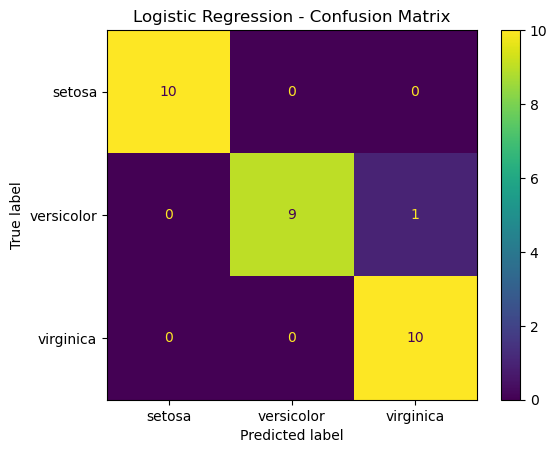

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrix তৈরি
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

# Confusion matrix display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=iris.target_names
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [46]:
from sklearn.metrics import classification_report

print("Logistic Regression - Classification Report")
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=iris.target_names
    )
)

Logistic Regression - Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [48]:
from sklearn.neighbors import KNeighborsClassifier

# KNN model তৈরি
knn_model = KNeighborsClassifier(n_neighbors=5)

# Training data দিয়ে model train
knn_model.fit(X_train, y_train)

print("KNN model trained successfully!")

KNN model trained successfully!


In [50]:
# Test data-এর species predict করা
y_pred_knn = knn_model.predict(X_test)

# প্রথম 10টি prediction দেখা
print("First 10 KNN Predictions:")
print(y_pred_knn[:10])

First 10 KNN Predictions:
[0 2 1 1 0 1 0 0 2 1]


In [52]:
# KNN accuracy calculate
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)
print("Accuracy Percentage:", knn_accuracy * 100, "%")

KNN Accuracy: 1.0
Accuracy Percentage: 100.0 %


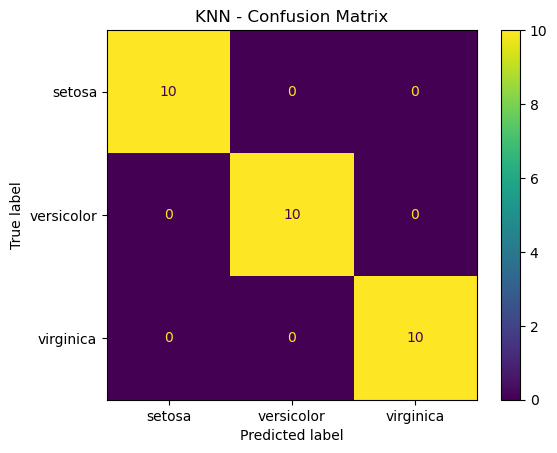

In [54]:
# KNN confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=iris.target_names
)

disp.plot()
plt.title("KNN - Confusion Matrix")
plt.show()

In [56]:
print("KNN - Classification Report")
print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=iris.target_names
    )
)

KNN - Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [58]:
print("KNN - Classification Report")
print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=iris.target_names
    )
)

KNN - Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [60]:
# দুইটি model-এর accuracy comparison

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN"
    ],
    "Accuracy": [
        logistic_accuracy,
        knn_accuracy
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.966667
1,KNN,1.000000


In [62]:
model_results["Accuracy (%)"] = model_results["Accuracy"] * 100

model_results

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.966667,96.666667
1,KNN,1.000000,100.000000


In [64]:
# Feature selection discussion

feature_discussion = pd.DataFrame({
    "Feature": [
        "sepal length (cm)",
        "sepal width (cm)",
        "petal length (cm)",
        "petal width (cm)"
    ],
    "Observation": [
        "Useful for classification",
        "More overlap between species",
        "Highly discriminative",
        "Highly discriminative"
    ]
})

feature_discussion

,Feature,Observation
0,sepal length (cm),Useful for classification
1,sepal width (cm),More overlap between species
2,petal length (cm),Highly discriminative
3,petal width (cm),Highly discriminative


In [66]:
if logistic_accuracy > knn_accuracy:
    best_model = "Logistic Regression"
    best_accuracy = logistic_accuracy
elif knn_accuracy > logistic_accuracy:
    best_model = "KNN"
    best_accuracy = knn_accuracy
else:
    best_model = "Logistic Regression and KNN"
    best_accuracy = logistic_accuracy

print("Best-performing model:", best_model)
print(f"Accuracy: {best_accuracy * 100:.2f}%")

Best-performing model: KNN
Accuracy: 100.00%


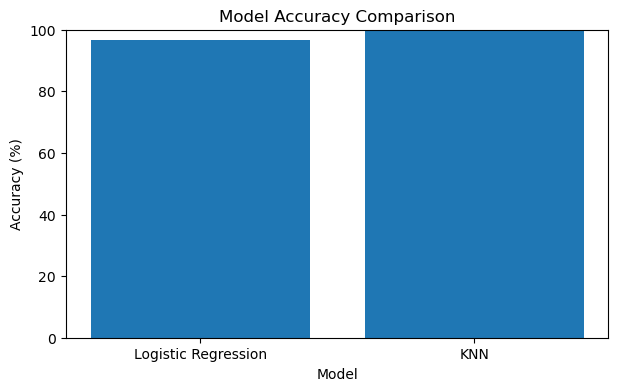

In [68]:
plt.figure(figsize=(7, 4))

plt.bar(
    model_results["Model"],
    model_results["Accuracy (%)"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.show()